# 03 - Descomposicion estacional (CPI Global)

Cuantificar la componente estacional de la tasa de inflacion global.

**Hipotesis:** al ser ya una tasa interanual, la estacionalidad deberia
ser menor que en el indice nivel de Espana (el calculo YoY ya suaviza
algunos efectos de calendario). Sin embargo pueden quedar efectos
residuales si el patron estacional no es exactamente anual.

**Metodos:** descomposicion clasica, STL, fuerza estacional Fs.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose, STL

NOTEBOOK_DIR = Path("C:/Users/usuario/OneDrive/Documentos/GitHub/tfg-ipc-mcp/tfg-forecasting/02_eda")
ROOT = NOTEBOOK_DIR.parent
MONOREPO = ROOT.parent
sys.path.insert(0, str(MONOREPO))

from shared.constants import DATE_TRAIN_END

plt.rcParams.update({"figure.figsize": (14, 8), "axes.grid": True, "grid.alpha": 0.3})


In [2]:
df = pd.read_parquet(ROOT / "data" / "processed" / "cpi_global_monthly.parquet")
train = df.loc[:DATE_TRAIN_END]
y = train["cpi_global_rate"]
y.index.freq = "MS"
print(f"Train: {len(y)} obs, {y.index.min().date()} -> {y.index.max().date()}")


Train: 228 obs, 2002-01-01 -> 2020-12-01


## 1. Descomposicion clasica - aditiva

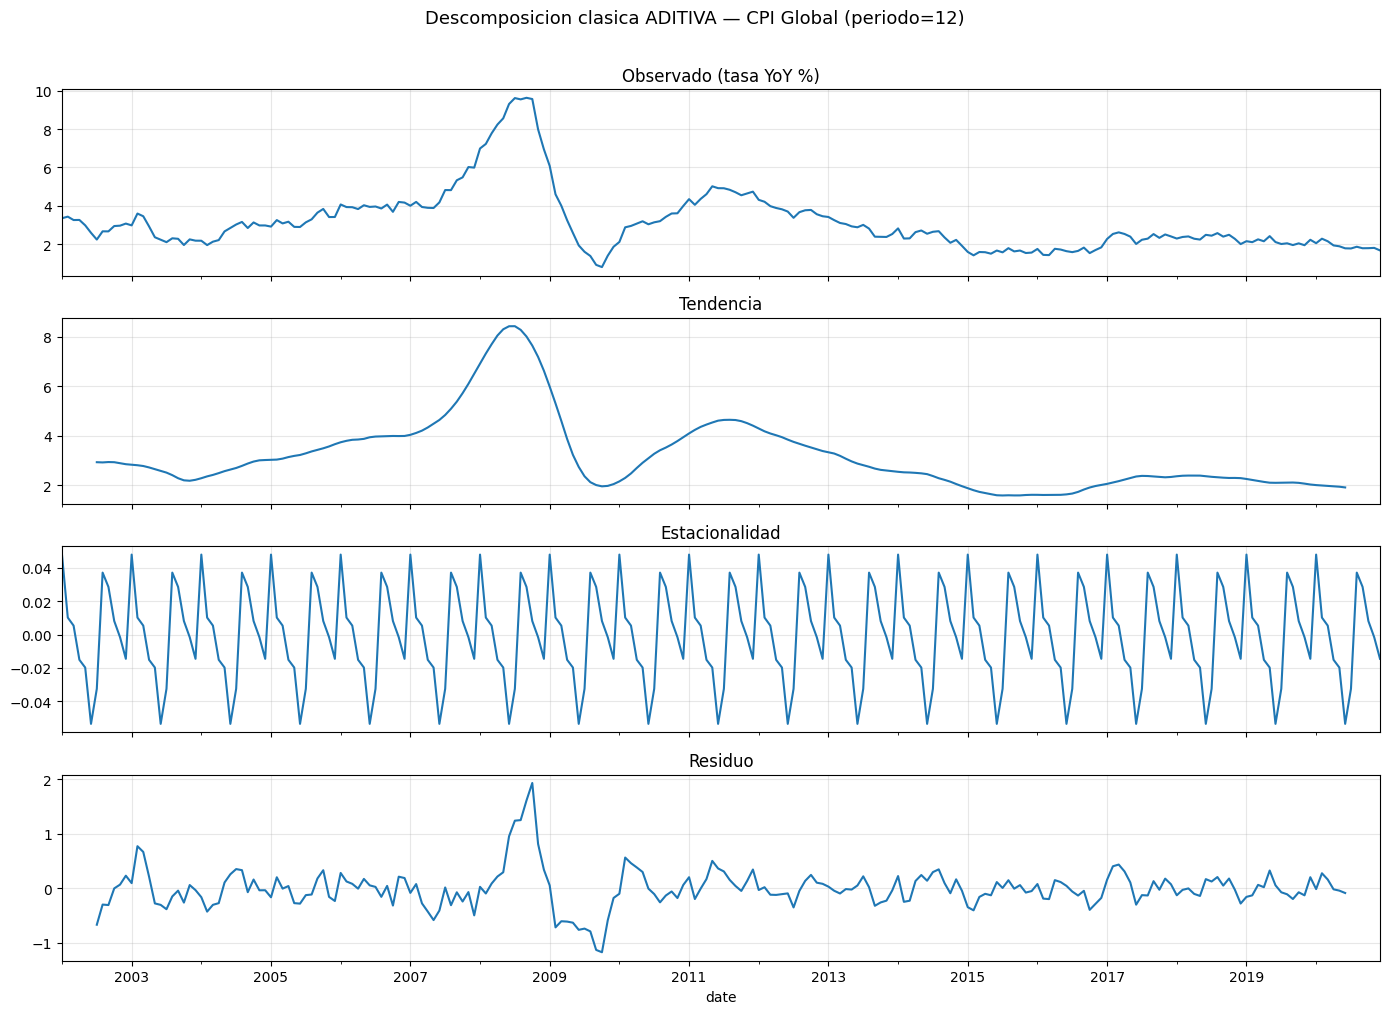

In [3]:
decomp_add = seasonal_decompose(y, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp_add.observed.plot(ax=axes[0], title="Observado (tasa YoY %)")
decomp_add.trend.plot(ax=axes[1], title="Tendencia")
decomp_add.seasonal.plot(ax=axes[2], title="Estacionalidad")
decomp_add.resid.plot(ax=axes[3], title="Residuo")
fig.suptitle("Descomposicion clasica ADITIVA - CPI Global (periodo=12)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 2. STL (LOESS) - robusto a outliers

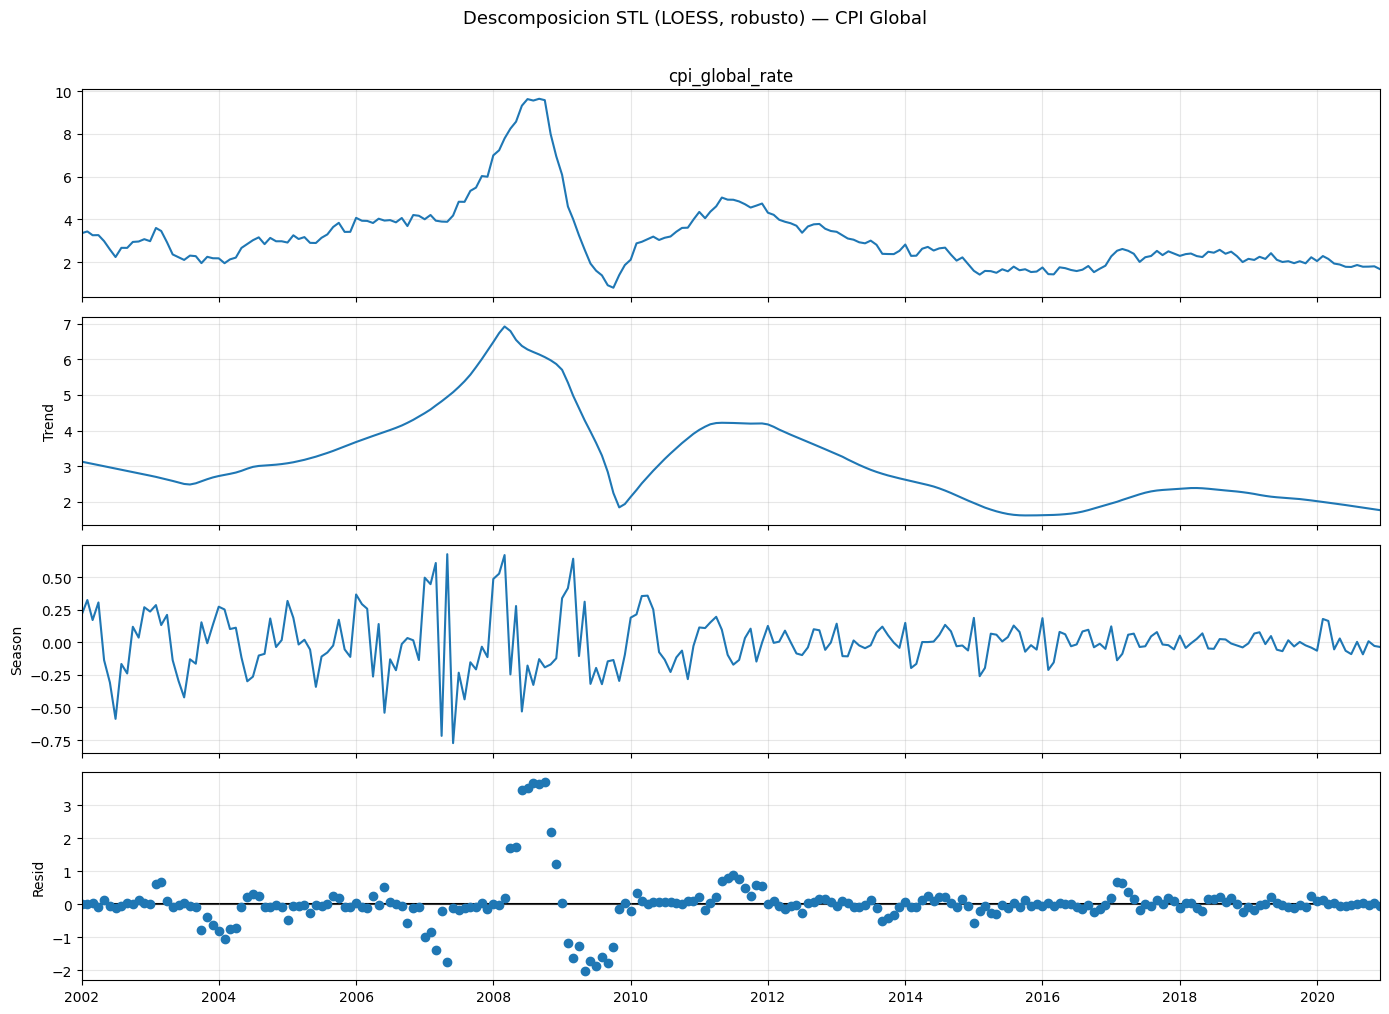

In [4]:
stl = STL(y, period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Descomposicion STL (LOESS, robusto) - CPI Global", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 3. Fuerza de la estacionalidad (Fs)

$F_s = 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}$

- $F_s > 0.64$ indica estacionalidad significativa
- Para la tasa YoY esperamos Fs menor que para el indice nivel de Espana


In [5]:
seasonal = stl_result.seasonal
resid = stl_result.resid

Fs = 1 - np.var(resid) / np.var(seasonal + resid)
print(f"Fuerza estacional (Fs): {Fs:.4f}")
print(f"Estacionalidad {'SIGNIFICATIVA' if Fs > 0.64 else 'NO significativa'} (umbral 0.64)")
print()
print(f"Varianza residuo:         {np.var(resid):.6f}")
print(f"Varianza (estac+residuo): {np.var(seasonal + resid):.6f}")
print(f"Varianza tendencia:       {np.var(stl_result.trend.dropna()):.6f}")


Fuerza estacional (Fs): -0.0781
Estacionalidad NO significativa (umbral 0.64)

Varianza residuo:         0.527639
Varianza (estac+residuo): 0.489415
Varianza tendencia:       1.542433


## 4. Patron estacional mensual

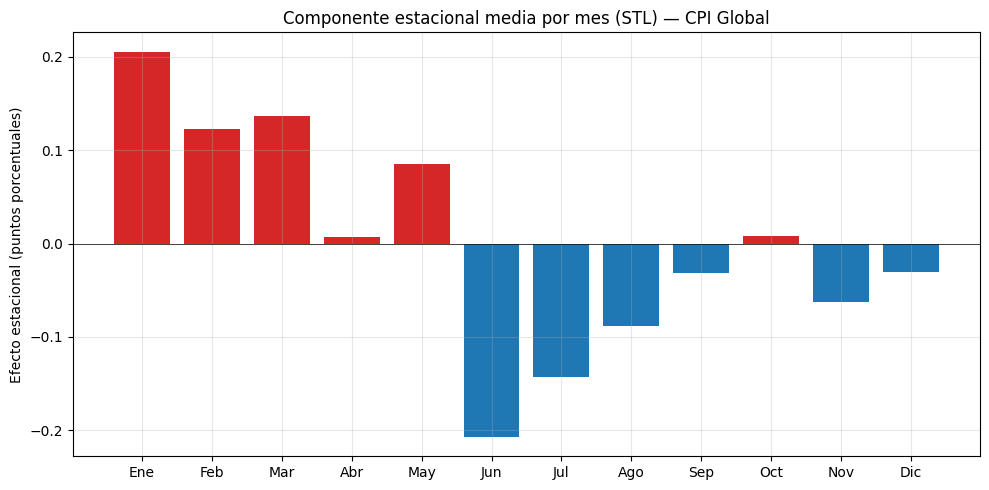

Patron estacional mensual:
  Ene: +0.2057
  Feb: +0.1227
  Mar: +0.1363
  Abr: +0.0069
  May: +0.0849
  Jun: -0.2073
  Jul: -0.1427
  Ago: -0.0881
  Sep: -0.0311
  Oct: +0.0080
  Nov: -0.0630
  Dic: -0.0304


In [6]:
seasonal_pattern = stl_result.seasonal.groupby(stl_result.seasonal.index.month).mean()

months = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
colors = ["#d62728" if v > 0 else "#1f77b4" for v in seasonal_pattern.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 13), seasonal_pattern.values, color=colors)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("Componente estacional media por mes (STL) - CPI Global")
ax.set_ylabel("Efecto estacional (puntos porcentuales)")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("Patron estacional mensual:")
for m, name in enumerate(months, 1):
    print(f"  {name}: {seasonal_pattern[m]:+.4f}")


## 5. Temporal Stability of Seasonality

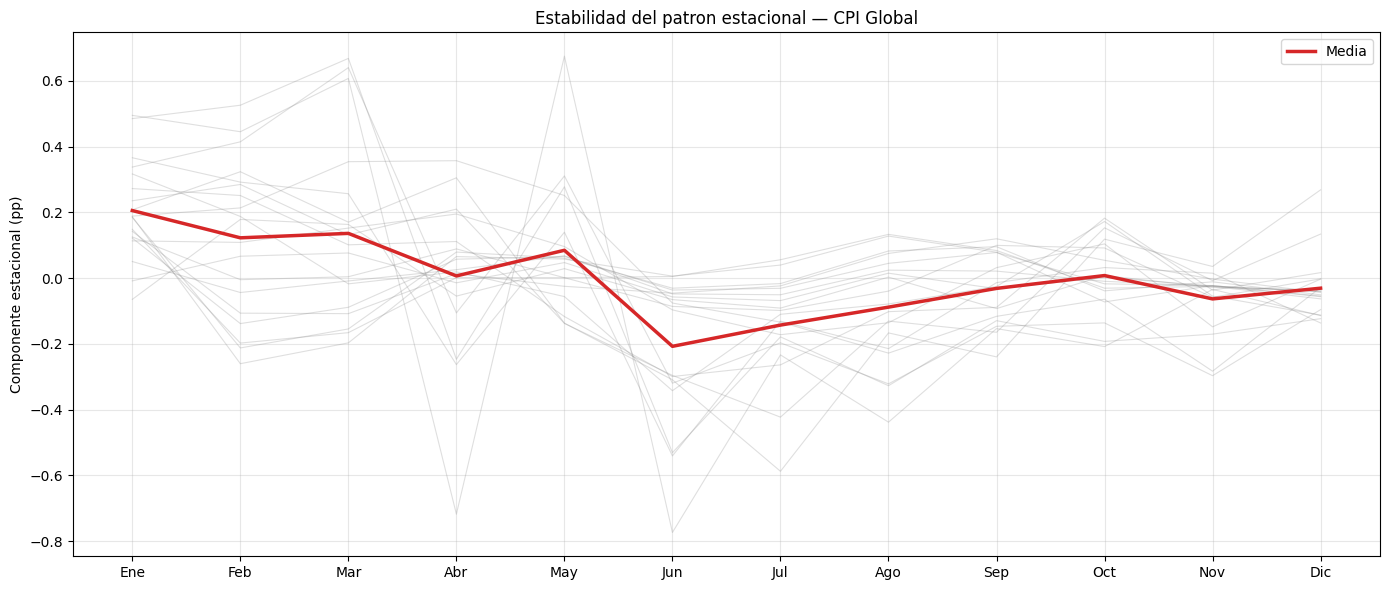

In [7]:
seasonal_by_year = pd.DataFrame({
    "year":     stl_result.seasonal.index.year,
    "month":    stl_result.seasonal.index.month,
    "seasonal": stl_result.seasonal.values,
})
pivot = seasonal_by_year.pivot(index="month", columns="year", values="seasonal")

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], alpha=0.25, linewidth=0.8, color="grey")
ax.plot(pivot.index, pivot.mean(axis=1), linewidth=2.5, color="#d62728", label="Media")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title("Seasonal Pattern Stability - Global CPI")
ax.set_ylabel("Componente estacional (pp)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Conclusion

**Resultados clave:**
- La descomposicion STL separa tendencia global, estacionalidad residual y ruido.
- Fs cuantifica si la estacionalidad en la tasa YoY es suficiente para
  justificar diferenciacion estacional (D=1) en SARIMA.
- Si Fs < 0.64: usar ARIMA(p,d,q) sin componente estacional explicita.
- Si Fs >= 0.64: usar SARIMA(p,d,q)(P,1,Q)12.

*Completar con valores reales de Fs y patron mensual tras ejecucion.*
